# Getting Global Warming Rates

Easier to do this with xarray than in R. Objective is simple, process full global timeline to table of global temperature and anomalies. Use that table to get global warming rates for the temperature report.

In [2]:
# Libraries
import requests
import os
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import oisstools as ot

# Set the workspace - local/ docker
box_root = ot.set_workspace("local")
box_root = box_root.replace("akemberling", "adamkemberling")

# Set the climatology period
reference_period = "1991to2020"

# Set climatology source choices
climatologies = {"1982to2011" : "1982to2011_climatology",
                 "1991to2020" : "1991to2020_climatology"}

climate_period = climatologies[reference_period]

# document what choices were made on last run:
print(f"Working via directory at: {box_root}")
print(f"Calculating Anomalies for {reference_period} reference period using {climate_period}")

Working via directory at: /Users/adamkemberling/Library/CloudStorage/Box-Box/
Calculating Anomalies for 1991to2020 reference period using 1991to2020_climatology


## Load Global OISST Anomalies

In [3]:
start_yr = 1981
end_yr   = 2025

# Load OISSt using ot.load_box_oisst()
oisst_anomalies = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = True, 
    do_parallel = True,
    reference_period = climate_period)

## Get Mean Time Series, and Area-Weighted Series

Pretty simple once the data is loaded to get the mean temperature or temperature anomaly across the lat lon dimensions.

For the global temperatures the size variation in grid cells moving poleward can distort overall temperatures. The following `ot.area_weighted_means` function will weight each cell by their relative 2-D physical areas.

In [4]:
# Timeline for global anomalies
# wonderful tool to calculate spatial mean by using dim variable names
mean_anomalies = oisst_anomalies.mean(['lat', 'lon']) 

# Get area-weighted means
weighted_means = ot.area_weighted_means(oisst_anomalies, var_name = "sst", sd = False)

# # Comparison Plot
# mean_anomalies.sst.plot(label = "Global - Un-Weighted")
# weighted_means.area_wtd_sst.plot(label = "Global - Area-Weighted")

## Convert To Table for Export

The next chunk drops the columns we don't need and joins the two time series into a single table for exporting it out.

In [ ]:
# convert anomalies to a dataframe from xr.array
anom_df = mean_anomalies.sst.to_dataframe()
# Convert area-weighted anomalies to dataframe
anoms_wtd = weighted_means.area_wtd_sst.to_dataframe()

# Drop columns we don't need
anom_df = anom_df.drop(columns = ["MOD", "modified_ordinal_day"])
anoms_wtd  = anoms_wtd.drop(columns = ["MOD", "modified_ordinal_day"])

# Join them
combined_anoms = anom_df.join(anoms_wtd, lsuffix = "_unwtd", rsuffix = "_wtd")

# Rename the columns
combined_anoms = combined_anoms.rename(columns = {"sst": "unweighted_sst_anom", "area_wtd_sst": "area_weighted_sst_anom"})
combined_anoms.tail()

# Close the dataset
oisst_anomalies.close()

,unweighted_sst_anom,area_weighted_sst_anom
time,,
2025-08-14 12:00:00,0.489820,0.542340
2025-08-15 12:00:00,0.484667,0.536193
2025-08-16 12:00:00,0.471655,0.521965
2025-08-17 12:00:00,0.462875,0.510986
2025-08-18 12:00:00,0.482242,0.526334


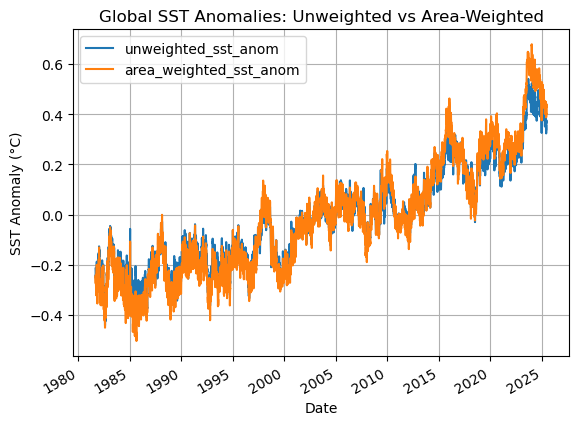

In [5]:

# Plot sst and area_wtd_sst together
combined_anoms.plot()
plt.legend()
plt.title("Global SST Anomalies: Unweighted vs Area-Weighted")
plt.ylabel("SST Anomaly (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

---

# Average Global Temps

Do the same steps but for raw temperature...

In [6]:
# Load temps
start_yr = 1981
end_yr   = 2025
# Load OISSt using ot.load_box_oisst()
oisst = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = False, 
    do_parallel = True)

## Timeline for global anomalies
# wonderful tool to calculate spatial mean by using dim variable names
mean_temps = oisst.mean(['lat', 'lon']) 

# Area Weighted Means
area_wtd_means = ot.area_weighted_means(oisst, var_name = "sst", sd = False)

In [7]:
# convert ssts to a dataframe from xr.array
sst_df = mean_temps.sst.to_dataframe()

# Convert area-weighted anomalies to dataframe
sst_wtd = area_wtd_means.area_wtd_sst.to_dataframe()

# # Drop columns we don't need
# sst_wtd  = sst_wtd.drop(columns = ["MOD", "modified_ordinal_day"])

# Join them
combined_sst = sst_df.join(sst_wtd, lsuffix = "_unwtd", rsuffix = "_wtd")

# Rename the columns
combined_sst = combined_sst.rename(columns = {"sst": "unweighted_sst", "area_wtd_sst": "area_weighted_sst"})
combined_sst.tail()

,unweighted_sst,area_weighted_sst
time,,
2025-08-14 12:00:00,14.520809,18.888399
2025-08-15 12:00:00,14.516904,18.883371
2025-08-16 12:00:00,14.504874,18.870359
2025-08-17 12:00:00,14.492225,18.857121
2025-08-18 12:00:00,14.509109,18.870203


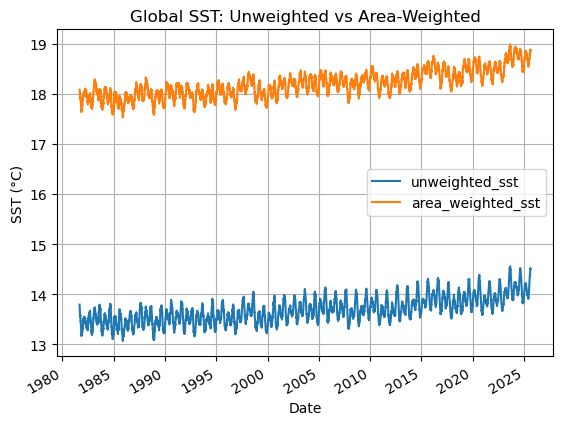

In [8]:
# Plot sst and area_wtd_sst together
combined_sst.plot()
plt.legend()
plt.title("Global SST: Unweighted vs Area-Weighted")
plt.ylabel("SST (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

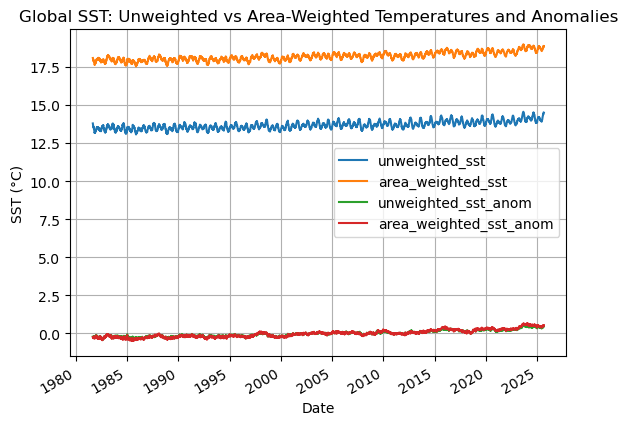

In [10]:
# Join the Temperatures and Anomalies
temp_and_anom = combined_sst.join(combined_anoms)
temp_and_anom.plot()
plt.legend()
plt.title("Global SST: Unweighted vs Area-Weighted Temperatures and Anomalies")
plt.ylabel("SST (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

In [11]:
# SAVING
combined_sst.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_temps_oisst.csv")
temp_and_anom.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_anoms_{reference_period}.csv")

# Close the dataset
oisst.close()
oisst_anomalies.close()